<a href="https://colab.research.google.com/github/devikarnambigai086-rgb/Oasis-Infobyte-DataScience-Internship/blob/main/Task2_Unemployment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving archive (9).zip to archive (9).zip


In [3]:
import zipfile

with zipfile.ZipFile("archive (9).zip", 'r') as zip_ref:
    zip_ref.extractall("unemployment_data")

import os
print(os.listdir("unemployment_data"))

['Unemployment_Rate_upto_11_2020.csv', 'Unemployment in India.csv']


# Task 2: Unemployment Analysis with Python
### Oasis Infobyte Data Science Internship

This notebook analyzes India's unemployment rate data (up to Nov 2020),
exploring trends across regions and the impact of COVID-19 lockdown period.

**Dataset:** Unemployment_Rate_upto_11_2020.csv  
**Libraries:** Pandas, Matplotlib, Seaborn

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("unemployment_data/Unemployment_Rate_upto_11_2020.csv")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [5]:
# Check column names and data info
print(df.columns.tolist())
df.info()

['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitud

In [6]:
# Clean column names (remove extra spaces)
df.columns = df.columns.str.strip()
print(df.columns.tolist())

# Convert Date to datetime format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Check for missing values
print(df.isnull().sum())

# Rename long columns for easier use
df.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate'
}, inplace=True)

df.head()

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64


,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Region.1,longitude,latitude
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74


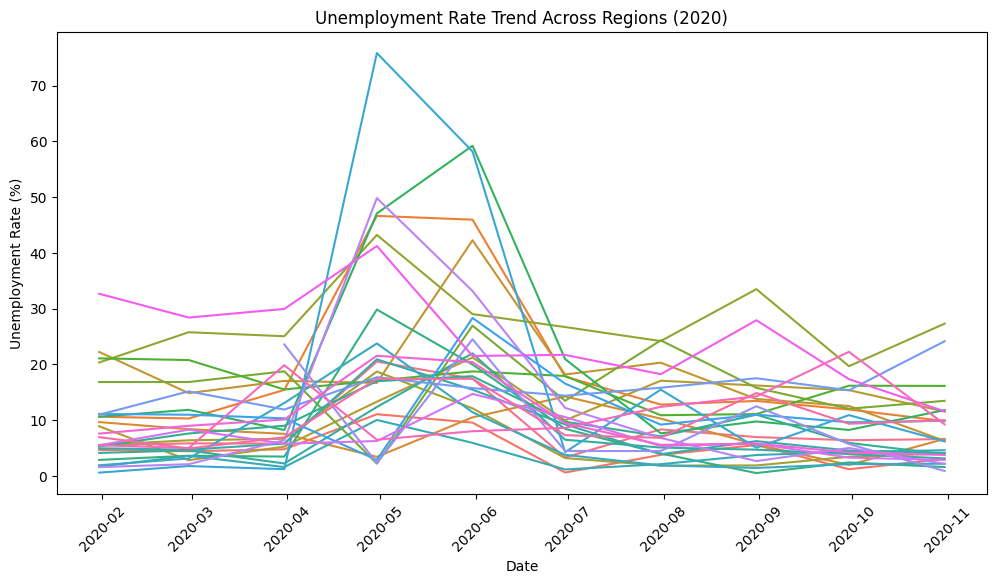

In [7]:
# Overall unemployment rate trend over time
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='Date', y='Unemployment_Rate', hue='Region', legend=False)
plt.title('Unemployment Rate Trend Across Regions (2020)')
plt.xlabel('Date')
plt# Top 10 states with highest average unemployment rate
state_avg = df.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=state_avg.values, y=state_avg.index, palette='Reds_r')
plt.title('Top 10 States by Average Unemployment Rate (2020)')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State')
plt.show().ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_502/575302553.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_avg.values, y=state_avg.index, palette='Reds_r')


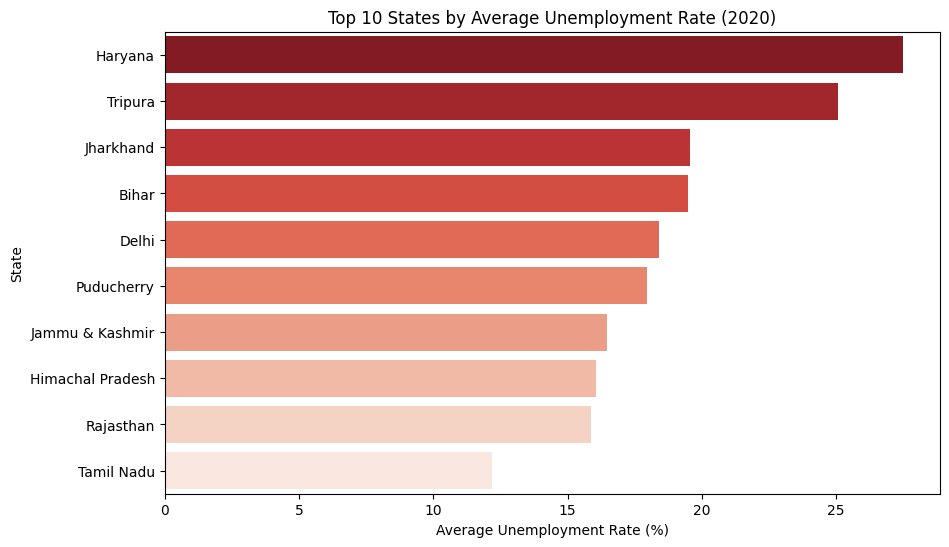

In [9]:
# Top 10 states with highest average unemployment rate
state_avg = df.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=state_avg.values, y=state_avg.index, palette='Reds_r')
plt.title('Top 10 States by Average Unemployment Rate (2020)')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State')
plt.show()

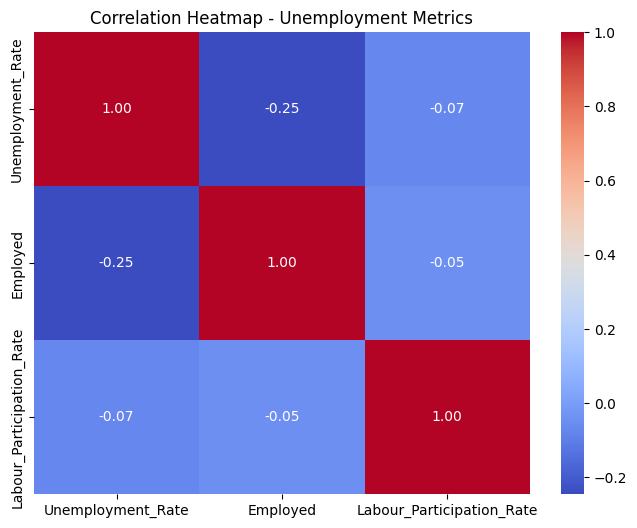

In [10]:
# Correlation heatmap
plt.figure(figsize=(8,6))
corr = df[['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Unemployment Metrics')
plt.show()

## Key Insights

1. **COVID-19 Impact:** Unemployment rate peaked sharply during April-May 2020,
   coinciding with the nationwide lockdown period.

2. **Worst-Affected States:** Haryana, Tripura, Jharkhand, Bihar, and Delhi
   recorded the highest average unemployment rates in 2020.

3. **Weak Correlation:** Unemployment rate shows a weak negative correlation
   (-0.25) with employed population, and negligible correlation with labour
   participation rate — indicating unemployment is driven more by external
   shocks (like COVID lockdown) than by structural labour market factors.

## Conclusion
This analysis highlights how the pandemic disrupted India's labour market
unevenly across regions, with states like Haryana and Bihar facing the
steepest unemployment surges.

---
**Tools used:** Python, Pandas, Matplotlib, Seaborn  
**Internship:** Oasis Infobyte Data Science Internship — Task 2